# DCIC First-Order Data Pipeline Check

Verifies end-to-end:
1. Raw annotations loaded as `n × K` probability arrays
2. Train / test split (folds 2-5 vs fold 1)
3. Sampled hard labels for both splits
4. DataLoaders via `get_data_train`
5. Model loaded from wandb via `load_model_for_evaluation`

In [1]:
# ── configuration ────────────────────────────────────────────────────────────
DATASET = "micebone"  # lowercase DCIC name
SEED = 1
VAL_SPLIT = 0.1
BATCH_SIZE = 32
NUM_WORKERS = 4

# ── wandb / model config ─────────────────────────────────────────────────────
# Fill in WANDB_RUN_ID to enable §5 (model loading + inference).
# Leave as None to skip those cells.
WANDB_RUN_ID = "3l1xzrgs"  # e.g. "abc123xy"
WANDB_ENTITY = "probly"  # e.g. "my-team"  (None = wandb default)
WANDB_PROJECT = "test"
METHOD_NAME = "credal_relative_likelihood"  # matches the method config name
BASE_MODEL = "resnet50"
MODEL_TYPE = "logit_classifier"
PRETRAINED = True

In [2]:
from collections import defaultdict
import json
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# make sure the src directory is on the path
sys.path.insert(0, str(Path().resolve().parent / "src"))

from probly_benchmark import data as benchmark_data
from probly_benchmark.data import (
    _DCIC_FOLDER_NAME,
    DCIC_IMAGE_PATH,
    TRANSFORMS_TEST,
    _DcicZeroOrderDataset,
)

print("imports OK")
print(f"DCIC image root: {DCIC_IMAGE_PATH}")

Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    /home/ra93hek/.cache/matplotlib/fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


imports OK
DCIC image root: /home/ra93hek/dev-benchmark-first-order/src/probly_benchmark/data/image


## 1 · Raw annotations as n × K array

Parse `annotations.json` directly and build a per-image probability matrix
where entry `[i, k]` is the fraction of annotators who assigned class `k` to image `i`.

In [3]:
def load_annotations(dataset_name: str):
    """Returns:
    -------
    image_paths   : list[str]      relative paths like 'fold1/img.png'
    prob_matrix   : np.ndarray     shape (n_images, n_classes) -- empirical p(y|x)
    classes       : list[str]      sorted class names
    fold_ids      : np.ndarray     fold number (1-5) for each image
    count_matrix  : np.ndarray     shape (n_images, n_classes) -- raw annotator counts
    """
    folder = _DCIC_FOLDER_NAME[dataset_name]
    root = DCIC_IMAGE_PATH / folder
    with (root / "annotations.json").open() as f:
        raw = json.load(f)

    prefix = folder + "/"
    img_to_labels: dict[str, list[str]] = defaultdict(list)
    for annotator in raw:
        for record in annotator["annotations"]:
            rel = record["image_path"].replace("\\\\", "/")
            rel = rel.removeprefix(prefix)
            img_to_labels[rel].append(record["class_label"])

    all_labels = sorted({l for lbls in img_to_labels.values() for l in lbls})
    label_to_int = {l: i for i, l in enumerate(all_labels)}
    K = len(all_labels)
    image_paths = sorted(img_to_labels.keys())
    n = len(image_paths)

    counts = np.zeros((n, K), dtype=np.int32)
    for i, p in enumerate(image_paths):
        for l in img_to_labels[p]:
            counts[i, label_to_int[l]] += 1

    probs = counts / counts.sum(axis=1, keepdims=True)
    fold_ids = np.array([int(p.split("/")[0].replace("fold", "")) for p in image_paths])
    return image_paths, probs, all_labels, fold_ids, counts


image_paths, prob_matrix, classes, fold_ids, count_matrix = load_annotations(DATASET)
K = len(classes)

print(f"Dataset      : {DATASET}")
print(f"Classes      : {classes}")
print(f"n images     : {len(image_paths)}")
print(f"prob_matrix  : shape {prob_matrix.shape}  dtype {prob_matrix.dtype}")
print(f"Folds present: {sorted(set(fold_ids.tolist()))}")
print()
print("First 5 rows of prob_matrix (empirical p(y|x)):")
header = "  ".join(f"{c:>6}" for c in classes)
print("  path                              | " + header)
for i in range(5):
    row = "  ".join(f"{prob_matrix[i, k]:6.3f}" for k in range(K))
    print(f"  {image_paths[i][:34]:<34} | {row}")

Dataset      : micebone
Classes      : ['g', 'nr', 'ug']
n images     : 7240
prob_matrix  : shape (7240, 3)  dtype float64
Folds present: [1, 2, 3, 4, 5]

First 5 rows of prob_matrix (empirical p(y|x)):
  path                              |      g      nr      ug
  fold1/g#_Mouse20_wt_Leg1_180522_10 |  1.000   0.000   0.000
  fold1/g#_Mouse20_wt_Leg1_180522_10 |  0.375   0.250   0.375
  fold1/g#_Mouse20_wt_Leg1_180522_10 |  0.750   0.125   0.125
  fold1/g#_Mouse20_wt_Leg1_180522_10 |  0.750   0.125   0.125
  fold1/g#_Mouse20_wt_Leg1_180522_10 |  1.000   0.000   0.000


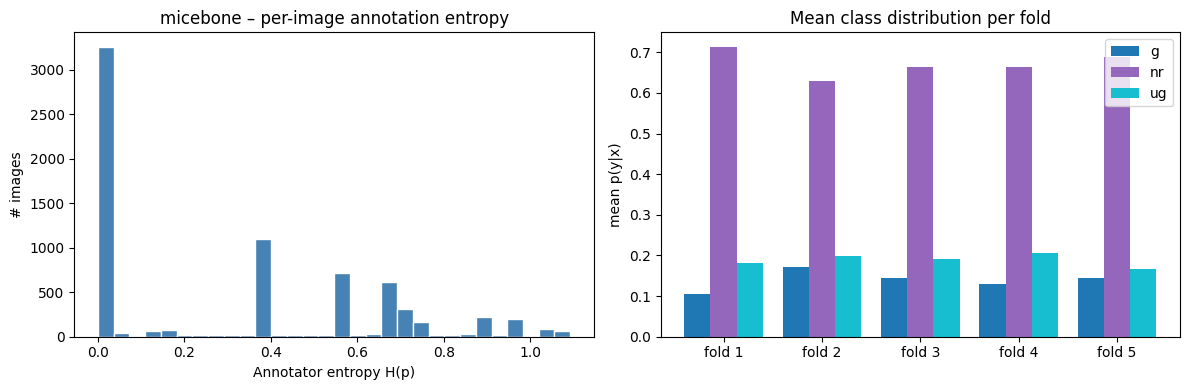

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eps = 1e-9
entropy = -(prob_matrix * np.log(prob_matrix + eps)).sum(axis=1)
axes[0].hist(entropy, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Annotator entropy H(p)")
axes[0].set_ylabel("# images")
axes[0].set_title(f"{DATASET} – per-image annotation entropy")

fold_nums = sorted(set(fold_ids.tolist()))
fold_means = np.array([prob_matrix[fold_ids == f].mean(axis=0) for f in fold_nums])
x = np.arange(len(fold_nums))
bar_width = 0.8 / K
colors = plt.cm.tab10(np.linspace(0, 0.9, K))
for k in range(K):
    axes[1].bar(x + k * bar_width, fold_means[:, k], bar_width, label=classes[k], color=colors[k])
axes[1].set_xticks(x + bar_width * (K - 1) / 2)
axes[1].set_xticklabels([f"fold {f}" for f in fold_nums])
axes[1].set_ylabel("mean p(y|x)")
axes[1].set_title("Mean class distribution per fold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2 · Train / Test split

- **Test** = fold 1
- **Train** = folds 2–5 (minus val split if any)

In [5]:
test_mask = fold_ids == 1
train_mask = fold_ids != 1

print("Split sizes")
print(f"  Test  (fold 1)   : {test_mask.sum()} images")
print(f"  Train (folds 2-5): {train_mask.sum()} images")
print()
for split_name, mask in [("Test ", test_mask), ("Train", train_mask)]:
    mean_p = prob_matrix[mask].mean(axis=0)
    parts = ", ".join(f"{c}={mean_p[i]:.3f}" for i, c in enumerate(classes))
    print(f"  {split_name} mean p(y|x): {parts}")

Split sizes
  Test  (fold 1)   : 1540 images
  Train (folds 2-5): 5700 images

  Test  mean p(y|x): g=0.106, nr=0.713, ug=0.181
  Train mean p(y|x): g=0.148, nr=0.661, ug=0.190


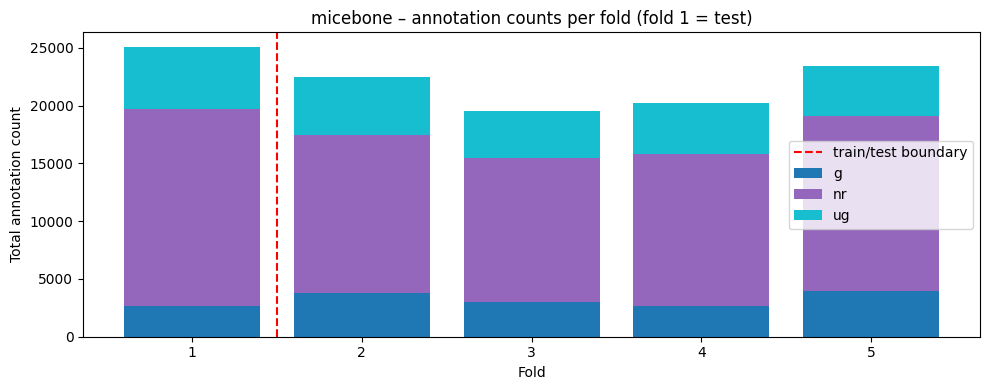

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
fold_counts = np.array([count_matrix[fold_ids == f].sum(axis=0) for f in fold_nums])
bottom = np.zeros(len(fold_nums))
for k in range(K):
    ax.bar(fold_nums, fold_counts[:, k], bottom=bottom, label=classes[k], color=colors[k])
    bottom += fold_counts[:, k]
ax.axvline(1.5, color="red", linestyle="--", linewidth=1.5, label="train/test boundary")
ax.set_xlabel("Fold")
ax.set_ylabel("Total annotation count")
ax.set_title(f"{DATASET} – annotation counts per fold (fold 1 = test)")
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Sampled hard labels

Each image gets one hard label drawn as `y ~ Categorical(empirical p(y|x))`.

In [7]:
folder = _DCIC_FOLDER_NAME[DATASET]
root = DCIC_IMAGE_PATH / folder
eval_tf = TRANSFORMS_TEST["imagenet"]

train_ds = _DcicZeroOrderDataset(root, folds=[2, 3, 4, 5], transform=eval_tf, seed=SEED)
test_ds = _DcicZeroOrderDataset(root, folds=[1], transform=eval_tf, seed=SEED)

train_labels = np.array(train_ds._labels)
test_labels = np.array(test_ds._labels)

print(f"Train: {len(train_ds)} images | classes: {train_ds.classes}")
print(f"Test : {len(test_ds)} images")
print()
print("First 10 train images:")
print(f"  {'filename':<45} {'ann counts':>20}  sampled")
for i in range(min(10, len(train_ds))):
    name = train_ds._image_paths[i].name
    ann = train_ds._annotation_lists[i]
    cnts = str([ann.count(k) for k in range(train_ds.num_classes)])
    sampled = train_ds.classes[train_labels[i]]
    print(f"  {name[:45]:<45} {cnts:>20}  → {sampled}")

Train: 5700 images | classes: ['g', 'nr', 'ug']
Test : 1540 images

First 10 train images:
  filename                                                ann counts  sampled
  g#_Mouse21_het_Leg1_180522_09-49-44#image_005          [0, 35, 46]  → ug
  g#_Mouse21_het_Leg1_180522_09-49-44#image_006          [8, 55, 18]  → ug
  g#_Mouse21_het_Leg1_180522_09-49-44#image_007           [75, 1, 5]  → g
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1           [79, 0, 2]  → g
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1          [58, 21, 2]  → g
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1           [70, 7, 4]  → g
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1          [23, 56, 2]  → g
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1          [47, 7, 27]  → ug
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1          [45, 33, 3]  → g
  g#_Mouse22_het_LTibiaUpperPart_180601_13-51-1          [38, 40, 3]  → ug


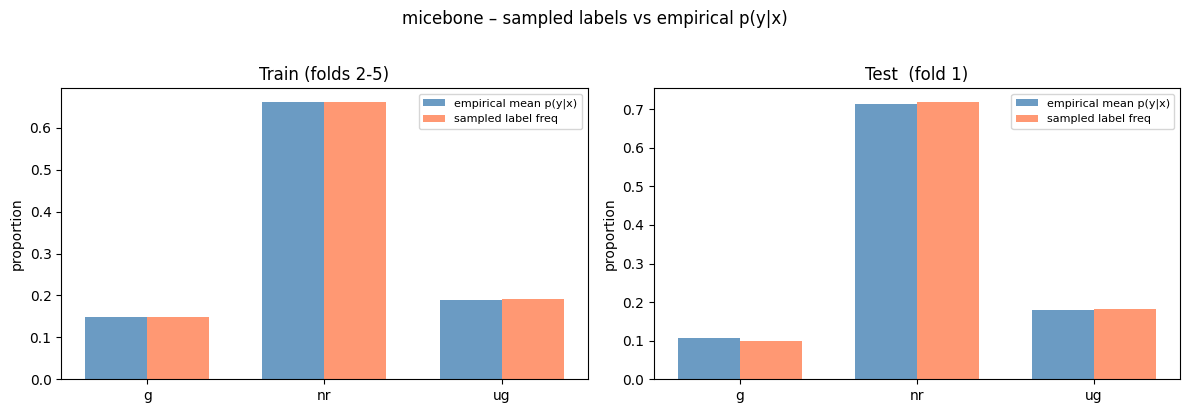

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, mask, split_name in [
    (axes[0], train_labels, train_mask, "Train (folds 2-5)"),
    (axes[1], test_labels, test_mask, "Test  (fold 1)"),
]:
    emp_mean = prob_matrix[mask].mean(axis=0)
    sampled_freq = np.bincount(labels, minlength=K) / len(labels)
    xk, w = np.arange(K), 0.35
    ax.bar(xk - w / 2, emp_mean, w, label="empirical mean p(y|x)", color="steelblue", alpha=0.8)
    ax.bar(xk + w / 2, sampled_freq, w, label="sampled label freq", color="coral", alpha=0.8)
    ax.set_xticks(xk)
    ax.set_xticklabels(classes)
    ax.set_ylabel("proportion")
    ax.set_title(split_name)
    ax.legend(fontsize=8)
plt.suptitle(f"{DATASET} – sampled labels vs empirical p(y|x)", y=1.02)
plt.tight_layout()
plt.show()

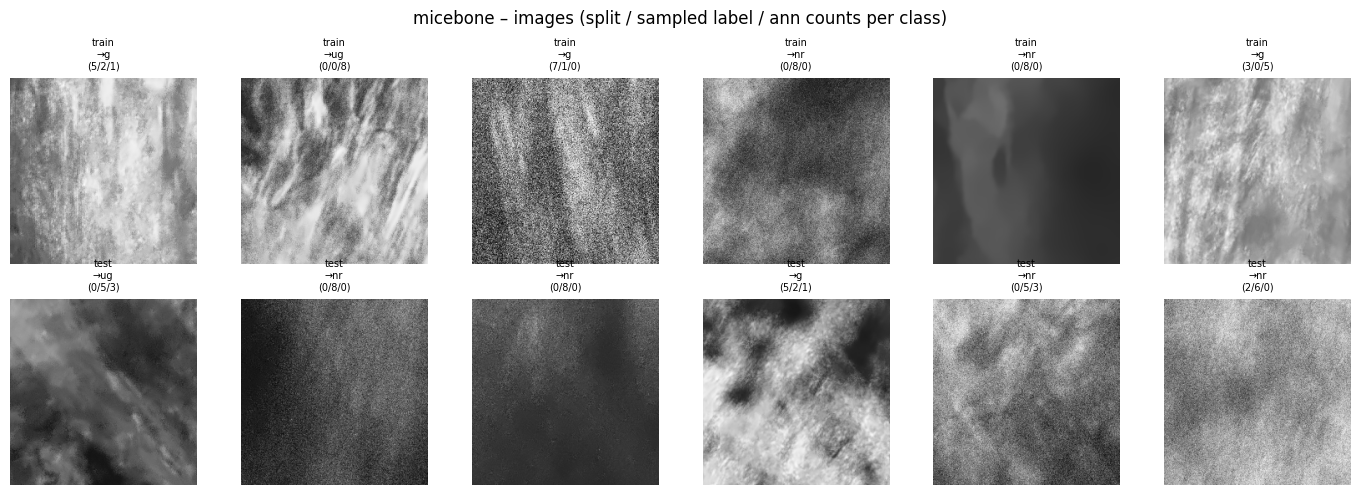

In [9]:
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(14, 5))
for row, (ds, labels, split_name) in enumerate(
    [
        (train_ds, train_labels, "train"),
        (test_ds, test_labels, "test"),
    ]
):
    idxs = random.sample(range(len(ds)), n_show)
    for col, idx in enumerate(idxs):
        img = Image.open(ds._image_paths[idx]).convert("RGB")
        sampled = ds.classes[labels[idx]]
        ann = ds._annotation_lists[idx]
        cnts_str = "/".join(str(ann.count(k)) for k in range(ds.num_classes))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{split_name}\n→{sampled}\n({cnts_str})", fontsize=7)
        axes[row, col].axis("off")
plt.suptitle(f"{DATASET} – images (split / sampled label / ann counts per class)")
plt.tight_layout()
plt.show()

## 4 · DataLoaders via `get_data_train`

In [10]:
loaders = benchmark_data.get_data_train(
    DATASET,
    seed=SEED,
    val_split=VAL_SPLIT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    pin_memory=False,
    persistent_workers=False,
)

print("DataLoaders:")
print(f"  train : {len(loaders.train.dataset)} samples")
print(f"  val   : {len(loaders.validation.dataset) if loaders.validation else 'None'} samples")
print(f"  cal   : {loaders.calibration}")
print(f"  test  : {len(loaders.test.dataset)} samples")

for split_name, loader in [("train", loaders.train), ("test", loaders.test)]:
    imgs, lbls = next(iter(loader))
    print(f"\n{split_name} batch:")
    print(f"  images : {tuple(imgs.shape)}  dtype={imgs.dtype}  min={imgs.min():.3f}  max={imgs.max():.3f}")
    print(f"  labels : {tuple(lbls.shape)}  dtype={lbls.dtype}  unique={lbls.unique().tolist()}")

DataLoaders:
  train : 5130 samples
  val   : 570 samples
  cal   : None
  test  : 1540 samples

train batch:
  images : (32, 3, 224, 224)  dtype=torch.float32  min=-2.084  max=2.570
  labels : (32,)  dtype=torch.int64  unique=[0, 1, 2]

test batch:
  images : (32, 3, 224, 224)  dtype=torch.float32  min=-2.101  max=2.605
  labels : (32,)  dtype=torch.int64  unique=[0, 1, 2]


## 5 · Model via wandb (`load_model_for_evaluation`)

Loads the model logged to wandb during training,
runs it on the test set, and compares predicted `p(y|x)`
against the empirical annotation distribution.

In [11]:
if WANDB_RUN_ID is None:
    print("WANDB_RUN_ID is None — skipping model sections.")
    print("Set WANDB_RUN_ID (and optionally WANDB_ENTITY / WANDB_PROJECT) at the top.")

In [12]:
if WANDB_RUN_ID is not None:
    from omegaconf import OmegaConf

    from probly_benchmark import utils
    from probly_benchmark.utils import load_model_for_evaluation

    # Construct the minimal DictConfig that load_model_for_evaluation expects.
    # It mirrors the fields train.py would have populated from Hydra.
    wandb_block = {"run_id": WANDB_RUN_ID}
    if WANDB_ENTITY is not None:
        wandb_block["entity"] = WANDB_ENTITY
    if WANDB_PROJECT is not None:
        wandb_block["project"] = WANDB_PROJECT

    cfg = OmegaConf.create(
        {
            "dataset": DATASET,
            "base_model": BASE_MODEL,
            "model_type": MODEL_TYPE,
            "pretrained": PRETRAINED,
            "seed": SEED,
            "val_split": VAL_SPLIT,
            "cal_split": 0.0,
            "method": {"name": METHOD_NAME},
            "wandb": wandb_block,
        }
    )

    device = utils.get_device(None)
    print(f"Device: {device}")

    model, _, run_id = load_model_for_evaluation(cfg, device)
    model.eval()
    print(f"Loaded model from wandb run: {run_id}")

/home/ra93hek/dev-benchmark-first-order/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/ra93hek/.netrc.


Device: cuda:1


wandb: Downloading large artifact 'credal_relative_likelihood_resnet50_micebone_1:latest', 900.16MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.3 (3013.4MB/s)


Loaded model from wandb run: 3l1xzrgs


In [17]:
if WANDB_RUN_ID is not None:
    from probly_benchmark.utils import collect_outputs_targets_raw

    # model may be a ModuleList of ensemble members (e.g. credal_relative_likelihood)
    members = list(model) if isinstance(model, torch.nn.ModuleList) else [model]

    all_member_logits = []
    for member in members:
        member.eval()
        logits_m, targets = collect_outputs_targets_raw(member, loaders.test, device, amp_enabled=False)
        all_member_logits.append(logits_m)

    # average logits across members
    logits = torch.stack(all_member_logits).mean(dim=0)  # (n_test, K)
    probs = logits.softmax(dim=-1)
    preds = probs.argmax(dim=-1)
    acc = (preds == targets).float().mean().item()

    print(f"Test samples : {len(targets)}")
    print(f"Logits shape : {tuple(logits.shape)}  (averaged over {len(members)} members)")
    print(f"Accuracy     : {acc:.4f}")
    print()
    print("Per-class accuracy:")
    for k, cls in enumerate(test_ds.classes):
        m = targets == k
        if m.sum() == 0:
            print(f"  {cls}: no samples")
        else:
            print(f"  {cls}: {(preds[m] == k).float().mean():.4f}  ({m.sum()} samples)")

Batch: 100%|██████████| 49/49 [00:02<00:00, 16.90it/s]

Test samples : 1540
Logits shape : (1540, 3)  (averaged over 10 members)
Accuracy     : 0.7968

Per-class accuracy:
  g: 0.0065  (154 samples)
  nr: 0.9602  (1106 samples)
  ug: 0.5857  (280 samples)


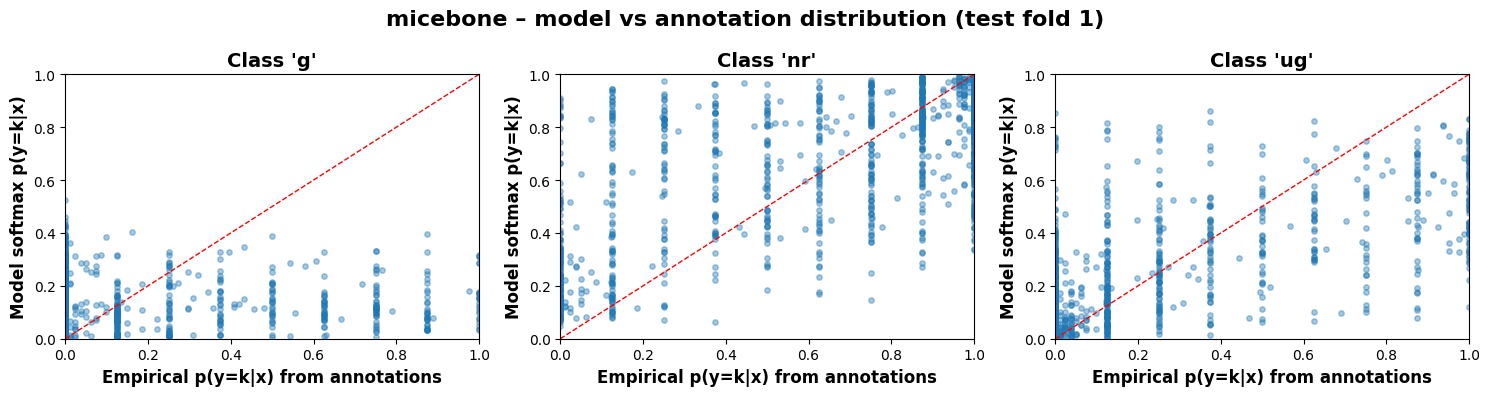

In [25]:
if WANDB_RUN_ID is not None:
    # Align test_ds order with prob_matrix order using filename as key
    name_to_emp = {Path(p).name: prob_matrix[i] for i, p in enumerate(image_paths) if fold_ids[i] == 1}
    test_names = [p.name for p in test_ds._image_paths]
    emp_probs_test = np.array([name_to_emp.get(n, np.full(K, np.nan)) for n in test_names])
    model_probs = probs.numpy()  # (n_test, K)

    fig, axes = plt.subplots(1, K, figsize=(5 * K, 4))
    if K == 1:
        axes = [axes]
    for k, (ax, cls) in enumerate(zip(axes, test_ds.classes)):
        valid = ~np.isnan(emp_probs_test[:, k])
        ax.scatter(emp_probs_test[valid, k], model_probs[valid, k], alpha=0.4, s=15)
        ax.plot([0, 1], [0, 1], "r--", linewidth=1)
        ax.set_xlabel("Empirical p(y=k|x) from annotations")
        ax.set_ylabel("Model softmax p(y=k|x)")
        ax.set_title(f"Class '{cls}'")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    plt.suptitle(f"{DATASET} – model vs annotation distribution (test fold 1)")
    plt.tight_layout()
    plt.show()